### Importación de librerías

In [109]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

### Carga de datos

##### Dataset con todas las variables

In [110]:
df_adop_all = pd.read_csv("../data/Clean/pet_adoption_data_clean_all.csv")

In [111]:
df_adop_all.columns

Index(['WeightKg', 'Vaccinated', 'HealthCondition', 'TimeInShelterDays',
       'AdoptionFee', 'PreviousOwner', 'target', 'AgeYears', 'PetType_Bird',
       'PetType_Cat', 'PetType_Dog', 'PetType_Rabbit',
       'Breed_Golden Retriever', 'Breed_Labrador', 'Breed_Parakeet',
       'Breed_Persian', 'Breed_Poodle', 'Breed_Rabbit', 'Breed_Siamese',
       'Color_Black', 'Color_Brown', 'Color_Gray', 'Color_Orange',
       'Color_White', 'Size_Large', 'Size_Medium', 'Size_Small'],
      dtype='object')

### Modelo 1: Logistic Regression

##### Modelo con todas las variables (df_adop_all)

In [112]:
X = df_adop_all.drop(["target"], axis = 1)
y = df_adop_all["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

##### Escalado de variables numéricas

In [113]:
numericas = ["WeightKg", "TimeInShelterDays", "AdoptionFee", "AgeYears"]

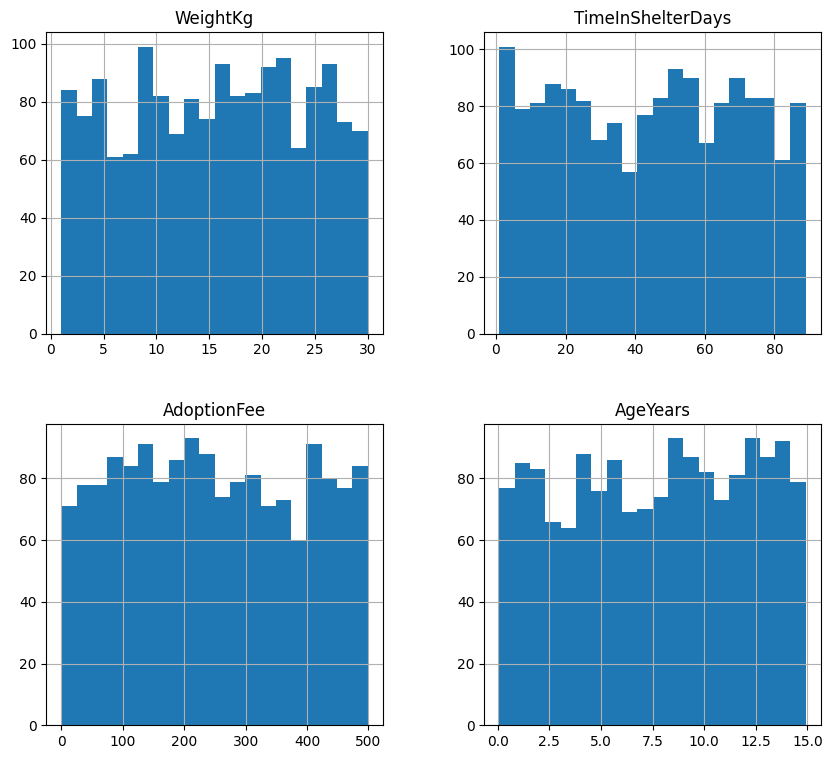

In [114]:
X_train[numericas].hist(bins=20, figsize=(10, 9)) 
plt.show()

- Distribuciones centradas 
- Ausencia de colas extremas o asimetrías
- No hay picos raros ni outliers

No hay que hacerle ninguna transformación a las variables numéricas (salvo escalado)

In [115]:
# Estandarización:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train[numericas])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


##### Transformación en train y test

In [116]:
X_train[numericas] = scaler.transform(X_train[numericas])
X_test[numericas] = scaler.transform(X_test[numericas])

In [117]:
X_train[numericas].describe()

,WeightKg,TimeInShelterDays,AdoptionFee,AgeYears
count,1.605000e+03,1.605000e+03,1.605000e+03,1.605000e+03
mean,-4.980440e-17,3.541646e-17,1.881499e-17,1.770823e-16
std,1.000312e+00,1.000312e+00,1.000312e+00,1.000312e+00
min,-1.764517e+00,-1.679498e+00,-1.726193e+00,-1.752290e+00
25%,-8.256426e-01,-9.024457e-01,-8.547437e-01,-8.463472e-01
50%,3.152828e-02,3.001697e-02,-5.998179e-02,3.879588e-02
75%,8.392820e-01,8.459218e-01,8.532973e-01,8.869617e-01
max,1.740574e+00,1.739532e+00,1.752633e+00,1.677351e+00


In [118]:
X_test[numericas].describe()

,WeightKg,TimeInShelterDays,AdoptionFee,AgeYears
count,402.000000,402.000000,402.000000,402.000000
mean,0.061282,-0.049138,0.053541,0.032150
std,1.035172,0.999413,0.979420,1.021099
min,-1.762270,-1.679498,-1.712250,-1.752290
25%,-0.839195,-0.980151,-0.776313,-0.864836
50%,0.090047,-0.008836,0.117794,0.117373
75%,0.991820,0.807069,0.950900,0.926250
max,1.740952,1.739532,1.738690,1.677351


##### Preparación previa al modelo

En este caso, la variable objetivo es una variable binaria. En la observación de los datos (notebook_EDA), se aprecia desbalance entre la no adopción (0, más frecuente) con respecto a las adopcion (1). Por ello, voy a comprobar el porcentaje de desbalanceo que existe, para aplicarle el balanceo al crear el modelo.

In [119]:
# Comprobación del porcentaje de desbalanceo entre categorías:
y_train.value_counts(normalize = True)

target
0    0.671651
1    0.328349
Name: proportion, dtype: float64

Con el porcentaje obtenido, se observa un claro desbalance entre categorías. Esto, en cuanto al modelo, puede provocar que éste se incline hacia la categoría mayoritaria, no aprendiendo nada útil sobre las adopciones. Por ello, aplico class_weight = balanced, para paliar esta desigualdad entre clases.

In [120]:
log_reg_all = LogisticRegression (max_iter = 5000, class_weight = "balanced")
log_reg_all.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

##### Interpretación de los pesos

In [121]:
print(log_reg_all.coef_, "\n")
print(log_reg_all.intercept_, "\n")
print(log_reg_all.classes_)

[[ 0.01184647  2.71793026 -2.85959062  0.01049494 -0.09494851 -0.09497115
  -0.6722122  -0.20976401 -0.32592968  0.77098208 -0.23738604 -0.69221342
   1.83423158 -0.20976401 -0.43793204 -0.37103607 -0.23738604  0.11200236
   0.12879984 -0.02217399 -0.11805211  0.09843253 -0.08910392 -1.13073234
   2.03064215 -0.90200745]] 

[-2.02405441] 

[0 1]


- log_reg.coef_ : Los coeficientes en positivo, indican aumento la probabilidad de adopción, frente a los negativos, que la disminuyen.

- log_reg.intercept_ : Al obtener un valor negativo, el modelo tiende a predecir la "no adopción" dado que es la clase dominante de la variable.

- log_reg.classes_ : Orden en el que el modelo está trabajando. Relacionado con la variable target, por eso [0 1]

In [122]:
# Visualización más clara de los coeficientes:

coef= pd.Series(log_reg_all.coef_[0], index = X_train.columns)

coef_df = pd.DataFrame(coef.sort_values(ascending=False), columns=['Coefficient'])
coef_df

,Coefficient
Vaccinated,2.717930
Size_Medium,2.030642
Breed_Labrador,1.834232
PetType_Dog,0.770982
Color_Black,0.128800
Breed_Siamese,0.112002
Color_Orange,0.098433
WeightKg,0.011846
TimeInShelterDays,0.010495
Color_Brown,-0.022174


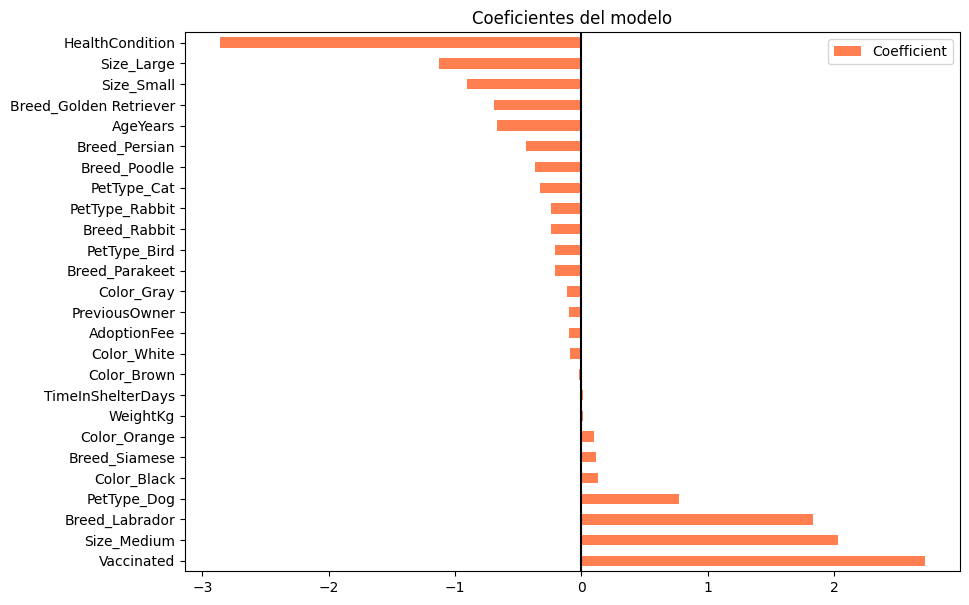

In [123]:
coef_df.plot(kind="barh", figsize=(10, 7), color="coral")
plt.axvline(0, color="black")
plt.title("Coeficientes del modelo")
plt.show()

##### Feature importance

In [124]:
intercept = log_reg_all.intercept_
coefs = log_reg_all.coef_.ravel()

features = pd.DataFrame(coefs, X_train.columns, columns=['coefficient']).copy()
features['coefficient'] = np.abs(features['coefficient'])

features.sort_values('coefficient', ascending=False).head()

,coefficient
HealthCondition,2.859591
Vaccinated,2.717930
Size_Medium,2.030642
Breed_Labrador,1.834232
Size_Large,1.130732


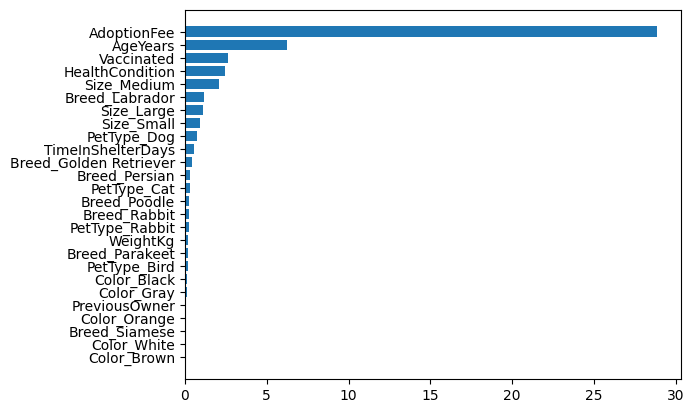

In [125]:
stdevs = []
for i in X_train.columns:
    stdev = df_adop_all[i].std()
    stdevs.append(stdev)

features["stdev"] = np.array(stdevs).reshape(-1,1)
features["importance"] = features["coefficient"] * features["stdev"]
features['importance_standarized'] = features['importance'] / y_train.std()

features = features.sort_values('importance_standarized', ascending=True)
plt.barh(features.index, features.importance_standarized);

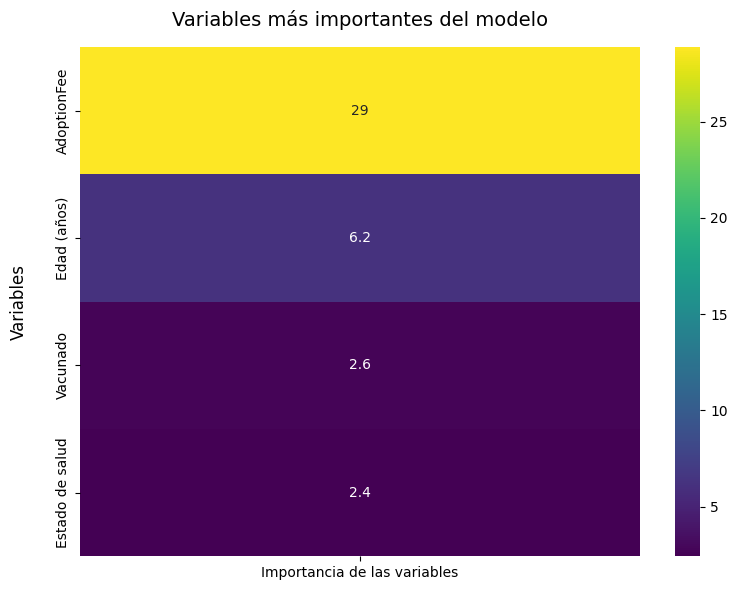

In [126]:
# PRESENTACIÓN

# Ordenar de mayor a menor
features_sorted = features.sort_values("importance_standarized", ascending=False)

# Seleccionar solo las 4 más importantes
top4 = features_sorted.head(4)
top4 = top4.rename(index = {"Vaccinated": "Vacunado", "HealthCondition": "Estado de salud",
                            "Size_Medium": "Tamaño mediano", "AgeYears": "Edad (años)"},
                            columns = {"importance_standarized": "Importancia de las variables"})

plt.figure(figsize=(8, 6))

sns.heatmap(
    top4[["Importancia de las variables"]],
    cmap="viridis",
    annot=True,
    cbar=True
)

plt.title("Variables más importantes del modelo", pad = 15, fontsize = 14)
plt.ylabel("Variables", labelpad = 20, fontsize = 12)
plt.tight_layout()
plt.show()

##### Accuracy

In [127]:
acc_train = round(accuracy_score(log_reg_all.predict(X_train), y_train), 3)
acc_test = round(accuracy_score(log_reg_all.predict(X_test), y_test), 3)

print("Accuracy train:", acc_train) # % total de aciertos
print("Accuracy test:", acc_test)

Accuracy train: 0.886
Accuracy test: 0.878


In [128]:
y_pred = log_reg_all.predict(X_test)

In [129]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred)) # % total de aciertos
print("Precision:", precision_score(y_test, y_pred)) # Cuántas adopciones realmente lo son
print("Recall:", recall_score(y_test, y_pred)) # Adopciones (1) reales capaces de detectar
print("F1:", f1_score(y_test, y_pred)) # Equilibrio entre precision y recall

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8781094527363185
Precision: 0.7677419354838709
Recall: 0.9015151515151515
F1: 0.8292682926829268
[[234  36]
 [ 13 119]]
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       270
           1       0.77      0.90      0.83       132

    accuracy                           0.88       402
   macro avg       0.86      0.88      0.87       402
weighted avg       0.89      0.88      0.88       402



El modelo funciona bien: 

- Acierta casi el 88% de los casos
- Tiene una precisión del 76% - 77% (acierta 3 de cada 4)
- Detecta más del 90% de adopciones reales
- Equilibrio grande entre precisión y recall (82.9%)

Matriz de confusión: 

- 234: Negativos reales, no adoptados predichos como no adoptados
- 36: Falsos positivos, sí adoptados que en realidad son no adoptados
- 13: Falsos negativos, no adoptados predichos que en realidad son sí adoptados (Muy pocos errores graves en la predicción)
- 119: Positivos reales, sí adoptados predichos como sí adoptados

In [130]:
# GridSearchCV log_reg.

***

### Comparación con otros modelos

In [131]:
features = X_train.columns.to_list()

scaler = StandardScaler()
X_train = X_train[features]
y_train = y_train.astype("int32")
X_test = X_test[features]
y_test = y_test.astype("int32")
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns= features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = features)

In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


tree_clf = DecisionTreeClassifier(max_depth=None, class_weight="balanced",random_state= 42)
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=None, class_weight="balanced",random_state= 42)
xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree= 0.8,
                        objective = "binary:logistic", eval_metric = "logloss", random_state = 42)
lgb_clf = LGBMClassifier(objective = "binary", random_state= 42, verbose = -100)


model_set = [log_reg_all, tree_clf, rf_clf, xgb_clf, lgb_clf]

model_names = ["LogisticRegression","DecisionTree","Random Forest","XGBoost","LightGBM"]

In [133]:
# Random Forest
rf_clf.fit(X_train, y_train)

# XGBoost
xgb_clf.fit(X_train, y_train)

# Árbol de decisión
tree_clf.fit(X_train, y_train)

# LGBM
lgb_clf.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Cross - Validation

In [134]:
y_train.unique()

array([1, 0], dtype=int32)

In [135]:
for nombre, modelo in zip(model_names, model_set):
    print(nombre, modelo.classes_ if hasattr(modelo, "classes_") else "sin clases")

LogisticRegression [0 1]
DecisionTree [0 1]
Random Forest [0 1]
XGBoost [0 1]
LightGBM [0 1]


In [136]:
X_train.dtypes

WeightKg                  float64
Vaccinated                  int64
HealthCondition             int64
TimeInShelterDays         float64
AdoptionFee               float64
PreviousOwner               int64
AgeYears                  float64
PetType_Bird                int64
PetType_Cat                 int64
PetType_Dog                 int64
PetType_Rabbit              int64
Breed_Golden Retriever      int64
Breed_Labrador              int64
Breed_Parakeet              int64
Breed_Persian               int64
Breed_Poodle                int64
Breed_Rabbit                int64
Breed_Siamese               int64
Color_Black                 int64
Color_Brown                 int64
Color_Gray                  int64
Color_Orange                int64
Color_White                 int64
Size_Large                  int64
Size_Medium                 int64
Size_Small                  int64
dtype: object

In [137]:
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set): 
    print(modelo)
    if nombre != "LogisticRegression":
        metricas_cv[nombre] = cross_val_score(modelo, X_train, y_train, cv = 3, scoring = "accuracy")
    else:
        metricas_cv[nombre] = cross_val_score(modelo, X_train_scaled, y_train, cv = 3, scoring = "accuracy")
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmax(valores)]

LogisticRegression(class_weight='balanced', max_iter=5000)
DecisionTreeClassifier(class_weight='balanced', random_state=42)
RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, .

In [138]:
# Hay hiperparámetros de XGBoost que he tenido que buscar en la guía que puso Jaime, porque ya no sabía por dónde me venían los errores 
# del bucle: objective = "binary:logisctic" (define el tipo de problema a resolver: clasificación binaria), 
# eval_metric = "logloss" (evalúa el modelo por dentro, pérdida logística)

In [139]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, Accuracy_CV: {np.mean(valores)}")
print(f"El ganador es {ganador}")

Model <LogisticRegression>, Accuracy_CV: 0.8803738317757009
Model <DecisionTree>, Accuracy_CV: 0.8760124610591901
Model <Random Forest>, Accuracy_CV: 0.9327102803738317
Model <XGBoost>, Accuracy_CV: 0.9302180685358256
Model <LightGBM>, Accuracy_CV: 0.9289719626168225
El ganador es Random Forest


Comparando los aciertos de todos los modelos entrenados, se concluye que el mejor modelo, con un acierto del 93.15% en la predicción de adopciones, es XGBoost

### Optimización de hiperparámetros del mejor de los modelos obtenidos (XGBoost)

In [140]:
params_grid = {
    "n_estimators": [100,200,400],
    "max_depth": [2,4,10],
    "min_samples_leaf": [10,20,40],
    "max_features": ["sqrt","log2",None],
    "max_samples": [0.3,0.6,1]
}

rf_grid = GridSearchCV(rf_clf,
                       param_grid= params_grid,
                       cv = 3,
                       scoring = "accuracy",
                       n_jobs = -1)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'max_features': ['sqrt', 'log2', ...], 'max_samples': [0.3, 0.6, ...], 'min_samples_leaf': [10, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [141]:
rf_grid.best_score_

np.float64(0.930841121495327)

In [142]:
rf_grid.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'max_samples': 0.6,
 'min_samples_leaf': 10,
 'n_estimators': 100}

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       270
           1       0.92      0.92      0.92       132

    accuracy                           0.95       402
   macro avg       0.94      0.94      0.94       402
weighted avg       0.95      0.95      0.95       402



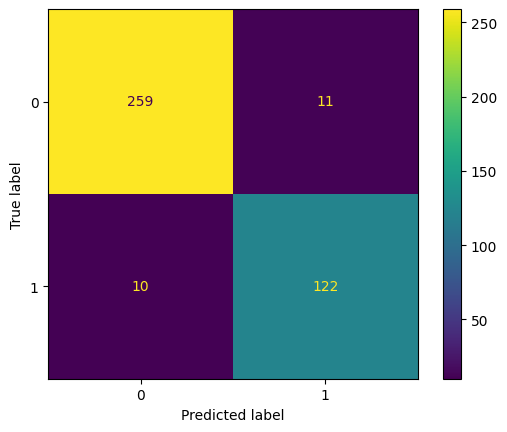

In [143]:
y_pred = rf_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

##### Interpretación del resultado:

XGBoost, proporciona una precisión y porcentaje de aciertos de más del 90%; así como detecta también más del 90% de adopciones reales.

En cuanto a la matriz de confusión, detecta:

- 261: Negativos reales, proporción de negativos predichos correctamente.
- 10: Falsos negativos, proporción de negativos predichos, que realmente son positivos
- 9: Falsos positivos, proporción de positivos predichos que realmente son negativos
- 122: Positivos reales, proporción de positivos predichos correctamente.

### Guardado de los modelos:

In [144]:
import joblib

In [145]:
# LogisticRegression, all_features

joblib.dump(log_reg_all, "../scr_models/LogisticRegression_all_features.pkl")

['../scr_models/LogisticRegression_all_features.pkl']

In [146]:
# DecissionTree

joblib.dump(tree_clf, "../scr_models/DecissionTree_model.pkl")

['../scr_models/DecissionTree_model.pkl']

In [147]:
# RandomForest

joblib.dump(rf_clf, "../scr_models/RandomForest_model.pkl")

['../scr_models/RandomForest_model.pkl']

In [148]:
# XGBoost

joblib.dump(xgb_clf, "../scr_models/XGBoost_modelo_main.pkl")

['../scr_models/XGBoost_modelo_main.pkl']

In [149]:
# LGBM

joblib.dump(lgb_clf, "../LGBM_model.pkl")

['../LGBM_model.pkl']

In [150]:
# Guardo el escalado para aplicarlo en el main

joblib.dump(scaler, "../scr_models/scaler.pkl")

['../scr_models/scaler.pkl']

### Prueba de modelo main (XGBoost_modelo_main)

In [151]:
features_model = xgb_clf.get_booster().feature_names
print(features_model)

['WeightKg', 'Vaccinated', 'HealthCondition', 'TimeInShelterDays', 'AdoptionFee', 'PreviousOwner', 'AgeYears', 'PetType_Bird', 'PetType_Cat', 'PetType_Dog', 'PetType_Rabbit', 'Breed_Golden Retriever', 'Breed_Labrador', 'Breed_Parakeet', 'Breed_Persian', 'Breed_Poodle', 'Breed_Rabbit', 'Breed_Siamese', 'Color_Black', 'Color_Brown', 'Color_Gray', 'Color_Orange', 'Color_White', 'Size_Large', 'Size_Medium', 'Size_Small']


In [152]:
df_predicciones = pd.read_csv("../data/Clean/predicciones.csv")

In [153]:
df_predicciones

,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AgeYears,PetType_Bird,PetType_Cat,PetType_Dog,...,Breed_Rabbit,Breed_Siamese,Color_Black,Color_Brown,Color_Gray,Color_Orange,Color_White,Size_Large,Size_Medium,Size_Small
0,10,1,0,12,100,0,5.0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
1,7,0,1,40,250,1,3.0,0,1,0,...,0,1,0,0,0,1,0,0,1,0
2,1,1,1,26,70,1,6.0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
3,20,1,1,32,300,1,3.0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
4,35,1,1,40,120,1,13.0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
5,15,1,0,28,57,0,10.0,0,0,0,...,1,0,0,0,0,0,1,0,0,1
6,2,1,0,3,250,0,0.5,0,1,0,...,0,0,0,1,0,0,0,1,0,0
7,3,1,1,20,232,0,0.6,0,0,1,...,0,0,0,1,0,0,0,0,1,0
8,45,1,0,50,452,0,6.0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
9,27,1,0,45,179,1,2.5,0,0,1,...,0,0,0,1,0,0,0,0,1,0


In [154]:
df_predicciones[numericas]

,WeightKg,TimeInShelterDays,AdoptionFee,AgeYears
0,10,12,100,5.0
1,7,40,250,3.0
2,1,26,70,6.0
3,20,32,300,3.0
4,35,40,120,13.0
5,15,28,57,10.0
6,2,3,250,0.5
7,3,20,232,0.6
8,45,50,452,6.0
9,27,45,179,2.5


In [155]:
scaler.feature_names_in_

array(['WeightKg', 'Vaccinated', 'HealthCondition', 'TimeInShelterDays',
       'AdoptionFee', 'PreviousOwner', 'AgeYears', 'PetType_Bird',
       'PetType_Cat', 'PetType_Dog', 'PetType_Rabbit',
       'Breed_Golden Retriever', 'Breed_Labrador', 'Breed_Parakeet',
       'Breed_Persian', 'Breed_Poodle', 'Breed_Rabbit', 'Breed_Siamese',
       'Color_Black', 'Color_Brown', 'Color_Gray', 'Color_Orange',
       'Color_White', 'Size_Large', 'Size_Medium', 'Size_Small'],
      dtype=object)

In [156]:
df_predicciones[numericas].columns

Index(['WeightKg', 'TimeInShelterDays', 'AdoptionFee', 'AgeYears'], dtype='object')

In [157]:
numericas2 = list(scaler.feature_names_in_)

In [158]:
df_predicciones_scaled = df_predicciones.copy()
df_predicciones_scaled[numericas2]=scaler.transform(df_predicciones[numericas2])
df_predicciones_scaled = df_predicciones_scaled[numericas2]

In [159]:
df_predicciones_scaled.to_csv("../data/Clean/predicciones_escaladas.csv", index = False)

In [160]:
xgb_clf = joblib.load("../scr_models/XGBoost_modelo_main.pkl")

In [161]:
print(sorted(xgb_clf.get_booster().feature_names))
print(sorted(df_predicciones_scaled.columns))

['AdoptionFee', 'AgeYears', 'Breed_Golden Retriever', 'Breed_Labrador', 'Breed_Parakeet', 'Breed_Persian', 'Breed_Poodle', 'Breed_Rabbit', 'Breed_Siamese', 'Color_Black', 'Color_Brown', 'Color_Gray', 'Color_Orange', 'Color_White', 'HealthCondition', 'PetType_Bird', 'PetType_Cat', 'PetType_Dog', 'PetType_Rabbit', 'PreviousOwner', 'Size_Large', 'Size_Medium', 'Size_Small', 'TimeInShelterDays', 'Vaccinated', 'WeightKg']
['AdoptionFee', 'AgeYears', 'Breed_Golden Retriever', 'Breed_Labrador', 'Breed_Parakeet', 'Breed_Persian', 'Breed_Poodle', 'Breed_Rabbit', 'Breed_Siamese', 'Color_Black', 'Color_Brown', 'Color_Gray', 'Color_Orange', 'Color_White', 'HealthCondition', 'PetType_Bird', 'PetType_Cat', 'PetType_Dog', 'PetType_Rabbit', 'PreviousOwner', 'Size_Large', 'Size_Medium', 'Size_Small', 'TimeInShelterDays', 'Vaccinated', 'WeightKg']


In [162]:
pred = xgb_clf.predict(df_predicciones_scaled)
proba = xgb_clf.predict_proba(df_predicciones_scaled)[:, 1]

pred, proba

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
 array([0.22957563, 0.06238072, 0.0188396 , 0.04841965, 0.10149284,
        0.21299118, 0.14868626, 0.09974302, 0.14578779, 0.91606694],
       dtype=float32))

### Interpretación de los resultados de la predicción

La predicción obtenida, es que únicamente el último animal de la predicción sería adoptado.

Las probabilidades de adopción de cada animal serían:

| Probabilidad de adopción | Animal | Peso | Vacunación | Sano | Días en el refugio | Cuota | Dueño previo | Edad (años) | Color del pelaje | Tamaño |
| ------------------------ | ------ | ---- | ---------- | ---- | ------------------ | ----- | ------------ | ---- | ---------------- | ------ |
| 22,96 % | Conejo | 10 kg | Sí | Sí | 12 | 100 | No | 5 | Marrón | Grande |
| 6,24 % | Gato Siamés | 7 kg | No | No | 40 | 250 | Sí | 3 | Naranja | Mediano |
| 1,88 % | Periquito | 1 kg | Sí | No | 26 | 70 | Sí | 6 | Gris | Pequeño |
| 4,84 % | Gato Persa | 20 kg | Sí | No | 32 | 300 | Sí | 3 | Marrón | Grande |
| 10,14 % | Perro Labrador | 35 kg | Sí | No | 400 | 120 | Sí | 13 | Negro | Grande |
| 21,30 % | Conejo | 15 kg | Sí | Sí | 28 | 57 | No | 10 | Blanco | Grande |
| 14,87% | Gato Persa | 2 kg | Sí | Sí | 3 | 250 | No | 6 (meses) | Marrón | Grande |
| 9,97 % | Perro Poodle | 3 kg | Sí | No | 20 | 232 | No | 7 (meses) | Marrón | Mediano |
| 14,56 % | Perro Golden Retriever | 45 kg | Sí | Sí | 50 | 452 | No | 6 | Naranja | Pequeño |
| 91,61 % | Perro Labrador | 27 kg | Sí | Sí | 45 | 179 | Sí | 2.5 | Marrón | Mediano |

EXPLICACIÓN BONUS

He tenido que eliminar el LogisticRegression con las features correladas con la target, porque me salía error constantemente y no podía más. Ha sido imposible, y como de todas maneras me iba a quedar con el LogisticRegression de todas las features, lo he eliminado. En el EDA figura el estudio de todas las variables, y además tengo guardado el dataset que incluye únicamente las variables correladas. Pero habría que hacer el proceso entero otra vez para ver la diferencia. Y no tengo tiempo.
